# RetailMax: Missing Data Handling

**Executive question:** Can RetailMax trust its customer data when profitability decisions depend on incomplete records?

This guided notebook supports the online session. It focuses on business interpretation rather than advanced statistical theory. Clustering is mentioned only as a future topic.

## Learning outcomes
By the end of the exercise, participants should be able to:
1. identify and quantify missing values;
2. visualize missingness;
3. compare deletion and simple imputation;
4. assess how treatment changes business KPIs; and
5. recommend a transparent management response.

In [13]:
# Run this only if the standard libraries are unavailable in your environment.
# %pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

## 1. Load the RetailMax data
Keep the CSV in the same folder as this notebook. In Google Colab, upload the CSV when prompted by the file browser.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_FILE = Path("RetailMax_Customer_Analytics.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path("/content/RetailMax_Customer_Data.csv")

assert DATA_FILE.exists(), "Place RetailMax_Customer_Analytics.csv beside the notebook."
df = pd.read_csv(DATA_FILE)
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
df.head()

Rows: 800 | Columns: 15


,Customer_ID,Age,Annual_Income_INR,Region,Preferred_Channel,Loyalty_Status,Primary_Category,Purchase_Frequency,Average_Basket_Value_INR,Annual_Spend_INR,Average_Discount_Rate,Return_Rate,Customer_Satisfaction_10,Estimated_Gross_Profit_INR,Estimated_Profit_Margin
0,RM0001,37.0,571000.0,West,Online,Platinum,Grocery,14,3011.52,39314.28,21.9,10.9,9.3,6491.12,16.5
1,RM0002,40.0,996000.0,North,Omnichannel,Silver,Grocery,7,1475.50,10898.01,16.7,19.7,5.4,1549.84,14.2
2,RM0003,38.0,523000.0,North,Store,NaN,Grocery,20,1497.42,29015.26,6.9,6.8,6.2,6469.93,22.3
3,RM0004,18.0,1051000.0,North,Store,Silver,Grocery,48,2040.00,95467.31,8.4,13.8,8.7,18101.56,19.0
4,RM0005,53.0,279000.0,West,Store,NaN,Fashion,3,1353.56,4237.77,13.4,5.0,7.1,1562.33,36.9


### Discussion prompt
What is the unit of analysis? Which columns are likely to influence customer profitability?

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Customer_ID                 800 non-null    object 
 1   Age                         741 non-null    float64
 2   Annual_Income_INR           731 non-null    float64
 3   Region                      800 non-null    object 
 4   Preferred_Channel           800 non-null    object 
 5   Loyalty_Status              589 non-null    object 
 6   Primary_Category            800 non-null    object 
 7   Purchase_Frequency          800 non-null    int64  
 8   Average_Basket_Value_INR    800 non-null    float64
 9   Annual_Spend_INR            800 non-null    float64
 10  Average_Discount_Rate       800 non-null    float64
 11  Return_Rate                 774 non-null    float64
 12  Customer_Satisfaction_10    761 non-null    float64
 13  Estimated_Gross_Profit_INR  800 non

## 2. Audit missing values

In [19]:
missing_summary = (
    df.isna().sum().to_frame("Missing_Count")
      .assign(Missing_Percent=lambda x: 100*x["Missing_Count"]/len(df))
      .query("Missing_Count > 0")
      .sort_values("Missing_Percent", ascending=False)
)
missing_summary.round(2)

,Missing_Count,Missing_Percent
Loyalty_Status,211,26.38
Annual_Income_INR,69,8.62
Age,59,7.38
Customer_Satisfaction_10,39,4.88
Return_Rate,26,3.25


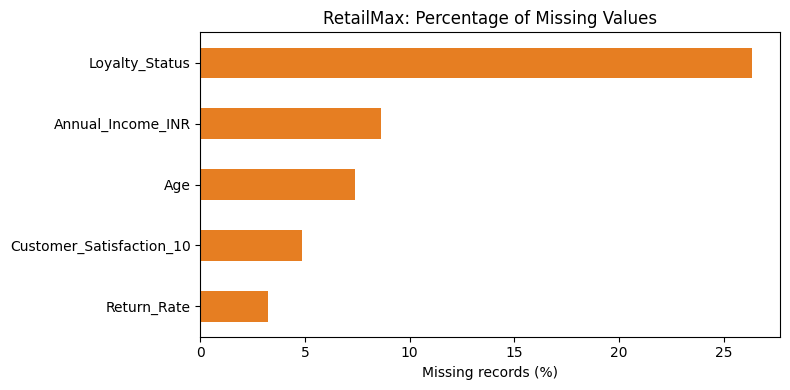

In [20]:
ax = missing_summary["Missing_Percent"].sort_values().plot(
    kind="barh", figsize=(8,4), color="#E67E22"
)
ax.set_title("RetailMax: Percentage of Missing Values")
ax.set_xlabel("Missing records (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretation**

Loyalty_Status is the largest data-quality concern. More than one-quarter of customers have no recorded loyalty status. This could weaken loyalty-tier comparisons and retention analysis.

The income and age gaps are smaller but still important because both variables may be used for customer profiling. Satisfaction and return-rate missingness is relatively limited, but these fields directly support customer-experience and operational-quality decisions.

### Interpretation questions
- Which missing field creates the greatest decision risk?
- Could the missingness be related to customer behaviour or the data-capture process?
- What should RetailMax investigate before imputing values?

## 3. Examine patterns behind missingness
This does not prove why data are missing. It helps identify patterns that management should investigate.

In [21]:
pattern_check = (
    df.assign(Income_Missing=df["Annual_Income_INR"].isna())
      .groupby(["Preferred_Channel", "Income_Missing"], dropna=False)
      .size().unstack(fill_value=0)
)
pattern_check["Missing_Percent"] = 100 * pattern_check.get(True, 0) / pattern_check.sum(axis=1)
pattern_check.round(2)

Income_Missing,False,True,Missing_Percent
Preferred_Channel,,,
Omnichannel,162,22,11.96
Online,241,17,6.59
Store,328,30,8.38


In [22]:
loyalty_missing = (
    df.assign(Loyalty_Missing=df["Loyalty_Status"].isna())
      .groupby("Preferred_Channel")["Loyalty_Missing"]
      .mean().mul(100).sort_values(ascending=False)
)
loyalty_missing.to_frame("Loyalty_Missing_Percent").round(2)

,Loyalty_Missing_Percent
Preferred_Channel,
Online,31.78
Omnichannel,30.98
Store,20.11


**Interpretation**

Income missingness varies across purchase channels. Omnichannel customers have the highest proportion of missing income at 11.96%, compared with 8.38% for Store and 6.59% for Online customers.

This does not prove why income is missing. However, it suggests that missingness may be associated with the channel or with differences in the customer-information collection process. RetailMax should examine how income information is requested, synchronized, or consolidated for omnichannel customers before assuming that the missing values are random.

## 4. Establish baseline business KPIs
Use available observations and clearly disclose the denominator.

In [23]:
def business_kpis(data, label):
    return pd.Series({
        "Scenario": label,
        "Rows": len(data),
        "Average Annual Spend": data["Annual_Spend_INR"].mean(),
        "Median Annual Income": data["Annual_Income_INR"].median(),
        "Average Satisfaction": data["Customer_Satisfaction_10"].mean(),
        "Average Return Rate": data["Return_Rate"].mean(),
        "Average Profit Margin": data["Estimated_Profit_Margin"].mean()
    })

baseline = business_kpis(df, "Available-case baseline")
baseline.to_frame("Value")

,Value
Scenario,Available-case baseline
Rows,800
Average Annual Spend,51647.923987
Median Annual Income,719000.0
Average Satisfaction,7.128515
Average Return Rate,10.770801
Average Profit Margin,25.061125


**Interpretation**

These values form the reference scenario against which deletion and imputation are evaluated.

However, the baseline calculations use available values separately for each KPI. For example, satisfaction is calculated from the non-missing satisfaction records, while income is calculated from the non-missing income records. Consequently, different indicators may use different effective sample sizes.

For executive reporting, the denominator for each KPI should therefore be disclosed.

## 5. Strategy A: Complete-case deletion
Deletion is easy but may remove many usable customer records and alter the composition of the sample.

In [24]:
analysis_cols = [
    "Age", "Annual_Income_INR", "Loyalty_Status",
    "Return_Rate", "Customer_Satisfaction_10"
]
df_deleted = df.dropna(subset=analysis_cols).copy()
print(f"Rows retained: {len(df_deleted):,} of {len(df):,} ({100*len(df_deleted)/len(df):.1f}%)")
deleted_kpis = business_kpis(df_deleted, "Complete-case deletion")

Rows retained: 465 of 800 (58.1%)


**Interpretation**

Complete-case deletion solves the missing-value problem by discarding customers who are incomplete on any of the selected variables. In this case, it removes nearly 42% of the customer base.

That level of data loss is substantial. It may reduce analytical reliability and change the composition of the remaining sample. Because missingness differs across channels, the deleted sample may underrepresent particular types of customers.

Therefore, complete-case deletion is easy to implement but difficult to justify as the default strategy for this dataset.

## 6. Strategy B: Simple, business-readable imputation
- Numeric variables: median, which is less sensitive to extreme values.
- Categorical loyalty status: explicit `Unknown`, preserving uncertainty rather than pretending to know the tier.

In [25]:
df_imputed = df.copy()
num_to_impute = ["Age", "Annual_Income_INR", "Return_Rate", "Customer_Satisfaction_10"]
for col in num_to_impute:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

df_imputed["Loyalty_Status"] = df_imputed["Loyalty_Status"].fillna("Unknown")
print(df_imputed[analysis_cols].isna().sum())
imputed_kpis = business_kpis(df_imputed, "Median + Unknown imputation")

Age                         0
Annual_Income_INR           0
Loyalty_Status              0
Return_Rate                 0
Customer_Satisfaction_10    0
dtype: int64


**Interpretation**

This is a transparent and business-readable treatment:

Numerical values are replaced with their respective medians.
Missing loyalty categories are not assigned to an existing loyalty tier.
Unknown preserves the fact that the original status was unavailable.

This strategy avoids the major information loss caused by deletion. However, median imputation reduces natural variation because multiple customers receive exactly the same replacement value. The imputed dataset remains suitable for teaching and descriptive analysis, but the treatment should be disclosed whenever results are presented.


## 7. Compare the management consequences

In [26]:
comparison = pd.DataFrame([baseline, deleted_kpis, imputed_kpis]).set_index("Scenario")
comparison.round({
    "Average Annual Spend":2, "Median Annual Income":2,
    "Average Satisfaction":2, "Average Return Rate":4,
    "Average Profit Margin":4
})

,Rows,Average Annual Spend,Median Annual Income,Average Satisfaction,Average Return Rate,Average Profit Margin
Scenario,,,,,,
Available-case baseline,800,51647.92,719000.0,7.13,10.7708,25.0611
Complete-case deletion,465,51121.08,752000.0,7.14,11.0778,25.1176
Median + Unknown imputation,800,51647.92,719000.0,7.13,10.7132,25.0611


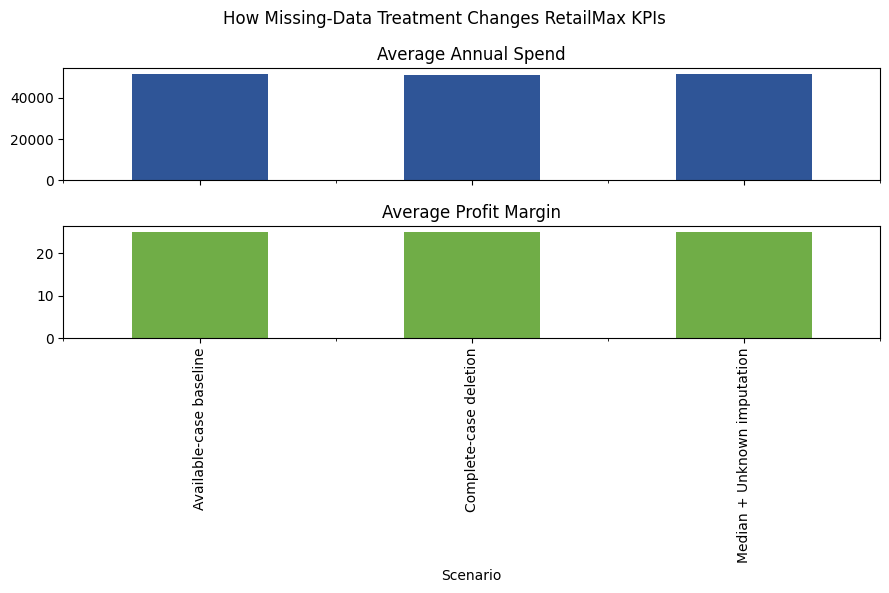

In [27]:
impact = comparison[["Average Annual Spend", "Average Profit Margin"]].copy()
impact.plot(kind="bar", subplots=True, figsize=(9,6), legend=False, color=["#2F5597", "#70AD47"])
plt.suptitle("How Missing-Data Treatment Changes RetailMax KPIs")
plt.tight_layout()
plt.show()

**Interpretation**

Complete-case deletion changes several indicators:

Average annual spend decreases by approximately 1.02%.
Median income increases by approximately 4.59%.
Average return rate increases by approximately 2.85%.
Average profit margin increases by approximately 0.23%.

The increase in median income is particularly important. Deleting incomplete records makes the retained customer group appear more affluent. This illustrates how deletion can alter the managerial profile of the customer base.

Median imputation has little effect on the displayed KPIs. Annual spend and profit margin remain exactly unchanged because those variables were not imputed. Satisfaction and return rate change only slightly because their missing values are replaced by their respective medians.

## 8. Sensitivity check: Mean versus median income imputation

In [28]:
income_compare = df[["Customer_ID", "Annual_Income_INR"]].copy()
income_compare["Income_Mean_Imputed"] = income_compare["Annual_Income_INR"].fillna(df["Annual_Income_INR"].mean())
income_compare["Income_Median_Imputed"] = income_compare["Annual_Income_INR"].fillna(df["Annual_Income_INR"].median())
income_compare[["Annual_Income_INR", "Income_Mean_Imputed", "Income_Median_Imputed"]].describe().round(2)

,Annual_Income_INR,Income_Mean_Imputed,Income_Median_Imputed
count,731.00,800.00,800.00
mean,1409907.27,1409907.27,1350316.52
std,7353991.56,7029285.25,7031964.08
min,185000.00,185000.00,185000.00
25%,520500.00,537750.00,537750.00
50%,719000.00,772500.00,719000.00
75%,1009000.00,1135250.00,984500.00
max,99999999.00,99999999.00,99999999.00


**Interpretation**

The mean is nearly twice the median because the dataset contains extremely high income values. Therefore, using mean imputation would assign approximately ₹1.41 million to every customer with missing income, while median imputation assigns ₹719,000.

Mean imputation also shifts the completed dataset’s median to ₹772,500. Median imputation preserves the median at ₹719,000.

For this dataset, median imputation is more defensible for a simple teaching exercise because it is less affected by extreme income values. Nevertheless, the unusual values should be investigated separately rather than being ignored merely because median imputation is used.

## 9. Managerial recommendation activity
Complete the decision statement:

> RetailMax should **[delete / impute / recollect / retain with disclosure]** the missing values in **[variable]** because **[business rationale]**. The main limitation is **[risk]**, and the company should improve **[data process]**.

There is no universal treatment. The choice must reflect the variable, cause of missingness, intended analysis, and cost of a wrong decision.

In [29]:
# Optional: export the cleaned teaching version
OUTPUT_FILE = "RetailMax_Customer_Analytics_Cleaned.csv"
df_imputed.to_csv(OUTPUT_FILE, index=False)
print(f"Saved: {OUTPUT_FILE}")

Saved: RetailMax_Customer_Analytics_Cleaned.csv


## Looking ahead
The cleaned dataset can later support customer segmentation through other predictive methods.
